# Worksheet 2.2-Tabular Methods: Monte Carlo

**Learning outcomes**
1. understand the difference between learning the expected return and computing it via dynamic programming
1. understand the strengths and weaknesses of MC methods
1. appreciating that MC methods need to wait till the end of the task to obtain its estimate of the expected return
1. compare MC methods with dynamic programming methods
1. understand the implication of satisfying and not satisfying the explore-start requirement for the MC control and how to mitigate it via the reward function
1. understand how to move from prediction to control by extending the V function to a Q function and make use of the idea of generalised policy iteration-GPI
1. understand how policy gradient methods work and appreciate how they differ from value function methods


In this worksheet we implement **Monte Carlo (MC) reinforcement learning methods**.

Unlike Dynamic Programming, which computes value functions using known environment dynamics, Monte Carlo methods **learn from experience** by interacting with the environment and estimating returns from sampled episodes.

This approach is particularly useful when the **transition dynamics are unknown**, but the agent can still generate experience by interacting with the environment.



## Plan

Reinforcement learning problems are typically divided into two categories.

**Prediction problems**  
The policy is fixed and the goal is to estimate the **value function** (expected return) for that policy. This is known as **policy evaluation**.

**Control problems**  
The goal is to find a **better or optimal policy**. Control methods estimate action values and improve the policy iteratively, typically through **Generalised Policy Iteration (GPI)**.

In this worksheet we proceed as follows:

1. Assume a **fixed policy** and estimate the state-value function (prediction).
2. Introduce **policy improvement** methods that compare and refine policies.
3. Extend these ideas to **control**, where evaluation and improvement are combined.

## RL Base Classes for Prediction vs Control: MRP, MDP and PG

The `rl` library provides three base classes that structure how algorithms interact with the environment and update their estimates.

Remember that in terms of class hierarchy:

```
MRP → MDP → PG
```

An **MRP** models only **states and rewards**, ignoring the effect of actions, and is therefore used for **prediction** problems.

- **Prediction algorithms** (e.g. TD) → use `MRP` to learn the **state-value function** `V`; policy is **stationary**
- **Control algorithms** (e.g. Q-learning, SARSA) → use `MDP` to learn the **action-value function** `Q`; policy is **ε-greedy**
- **Policy-gradient algorithms** (e.g. REINFORCE, Actor–Critic) → use `PG` to learn the **policy** `π` directly; policy is **softmax** or **Gaussian**


## MRP: Prediction Framework

The **Markov Reward Process (MRP)** class provides the main interaction engine between an agent and an environment.  
Its purpose is to estimate the **state-value function**

$$
V(s) = \mathbb{E}[G_t \mid S_t = s]
$$

which represents the expected discounted return from a state under a fixed policy.

The MRP class mainly provides the infrastructure needed to run reinforcement learning experiments.

### Main functionality of the Framework

The library provides a simple structure for implementing RL algorithms.

**Initialisation**: Defines the main training parameters such as the environment, learning rate, discount factor, num of episodes, and initialises the value table `V`.

**Online vs Offline Updates**: Algorithms can update in two ways:

- **online** – update after every step  
- **offline** – update at the end of each episode

**Step Functions**: Two step functions support different algorithm structures:

- `step_a()` – default step used by most algorithms (e.g. TD, Q-learning)  
- `step_an()` – used when the next action must be known in advance (e.g. SARSA)

**Interaction Loop**: The `interact()` function runs the training process:

    episodes → steps → updates

    For each episode the agent:
    
    1. resets the environment  
    2. interacts with it step by step  
    3. collects rewards  
    4. updates its value estimates

**Termination**: Episodes stop when a terminal state is reached or a maximum number of steps is exceeded.


In [1]:
# %cd ~/rl_rob 
# !git pull

In [2]:
%matplotlib inline

In [3]:
from env.grid.tabular import *
from rl.tabular import MRP, MDP, PG

Let us now move to define our 1st-visit Monte Carlo *prediction* method. This method averages the return for only the first visit of a state in each episode.

## First-Visit MC Policy Evaluation (Prediction)

As discussed in the lesson, Monte Carlo (MC) methods estimate the state-value function from experience. They approximate the cumulative *future* discounted reward by averaging the returns observed after visiting a state.

MC methods apply naturally to **episodic tasks**, since the return can only be computed once an episode has finished. This requirement is one of their main limitations, as the agent must wait until the end of the episode before updating its estimates.

Within a single episode, the agent may visit the same state multiple times. Returns can therefore be computed either from the **first visit** of the state or from **every visit**, leading to two variants of the algorithm.

The **first-visit MC** method updates the value estimate using only the return following the first occurrence of the state in an episode. In contrast, the **every-visit MC** method averages the returns following all occurrences of that state within the episode. First-visit MC is commonly used in tabular settings, whereas every-visit MC often integrates more naturally with function approximation methods.

In [4]:
class MC1st(MRP):

    def init(self):
        self.store = True
        self.ΣGs   = self.V*0      # the sum of returns for all episodes
        self.ΣepG = self.V*0      # counts for numbers of times we add to the return  

    # ----------------------------- 🌘 offline, MC learning: end-of-episode learning 🧑🏻‍🏫 --------------------------------    
    # MC1stVisit average all past visits to a state in all episodes to get its return estimates
    # we simply override the offline() function of the parent class
    def offline(self):

        #initialise the returns and their counts
        Gs = self.V*0
        epG = self.V*0

        # obtain the return for the latest episode
        Gt = 0
        for t in range(self.t, -1, -1):
            s = self.s[t]
            rn = self.r[t+1]

            Gt = self.γ*Gt + rn
            Gs[s] = Gt     # since we are moving backwards this will result in first visit return
            epG[s] = 1     # assign one to the counts since we are dealing with 1st visit

        # add the counts to the experience and obtain the average as per MC estimates
        self.ΣGs  += Gs    # add Vs (populated with Gt) to the sum of returns in different episodes
        self.ΣepG += epG   # add 1 to the states that has been 1st visited
        ind = epG>0        # avoids /0
        self.V[ind] = self.ΣGs[ind]/self.ΣepG[ind] # now average

That's it! Everything else is handled by the parent class, including the loop, interaction with the environment, and hyperparameters. 

Let us now try our new class to predict the values of a random walk MRP.

In [5]:
MC = MC1st(episodes=1000, seed=10).interact()
print(MC.V[1:-1])

[0.15780998 0.31454784 0.477      0.65342466 0.83831283]


As we can see the values are close to the analytical true values for this process given below.

In [6]:
pr = 1/(randwalk().nS-1) # 1/6 
np.arange(pr,1-pr, pr)   # true values

array([0.16666667, 0.33333333, 0.5       , 0.66666667, 0.83333333])

## MRP with visualisation

To help us visualise the learning that is taking place in each episode, we have created a set of visualisation functions that we will add to the MRP class. Familiarise yourself with these functions; they are self-explanatory. Mainly we have one function for plotting after each episode, not surprisingly called plot_ep(), and another function called plot_exp() that will be called at the end of the experience (after finishing all episodes). In addition, we have an Error() function to calculate the RMSE  between the true values and the predicted values of the states as well as plot_V() function that visualises the predicted values and true values to see visually how the algorithm is doing to come closer towards the true values.

As we did with the Grid class, we will call the child name the same name as the parent (MRP) to help us keep the code consistent and simplify the treatment of our classes when we import a class. The downside is that you would have to re-execute the first parent and its subsequent children if you want to make some changes to the class since it will keep adding to previous definitions, so please be mindful of this point.

We have also tried to reduce the overhead as much as possible for the new class by setting up visualisation only when it is necessary (when one of the plot functions is called)

### Applying MC1st on a prediction problem

Let us now run MC1st with the latest useful visualisation.

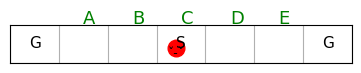

In [7]:
env = randwalk()
env.render(underhood='letters')
# env.fig.savefig("randomwalk.png", dpi=100, bbox_inches="tight")  


TypeError: 'NoneType' object is not subscriptable

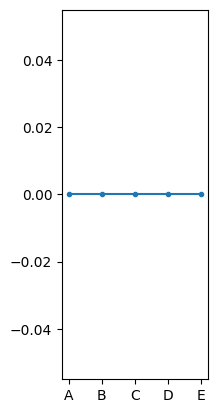

In [8]:
mc = MC1st(env=randwalk(), episodes=100, plotV=True, plotE=True, seed=1).interact()

As you can see we have called 
MC = MC1st(MRP)
to make sure that we are dealing with latest MRP definition.

In [ ]:
mc = MC1st(episodes=10, plotE=True).interact()

In [ ]:
mc = MC1st(episodes=10, plotV=True).interact()

Ok one more thing, to avoid passing the value of plotE=True, plotV=True, animate=True, whenever we want to demo a prediction algorithm, we can create a dictionary and store these values in it and then pass the reference to the MC1st call, below we show how.

In [ ]:
demoE = {'plotE':True, 'plotV':True, 'animate':True} # suitable for prediction

In [ ]:
mc = MC1st(episodes=100, **demoE, seed=1).interact()

In [ ]:
mc.ep

In [ ]:
mc.V

## First-visit MC control 

We now extend the MDP class, originally designed for value-function control, by overloading the `offline` function to implement a first-visit Monte Carlo control algorithm.

In [ ]:
class MC1stControl(MDP()):
        
    def init(self):
        self.store = True
        self.ΣQ   = self.Q*0      # the sum of returns for all episodes
        self.ΣepQ = self.Q*0      # counts for numbers of times we add to the return  
    
    def offline(self): 
        #initialise the values
        Qs = self.Q*0
        epQ= self.Q*0
        
        # obtain the return for the latest episode
        Gt = 0
        for t in range(self.t, -1, -1):
            s = self.s[t]
            a = self.a[t]
            rn = self.r[t+1]
            
            Gt = self.γ*Gt + rn
            Qs[s,a] = Gt
            epQ[s,a] = 1

        # add the counts to the experience and obtain the average as per MC estimates
        self.ΣQ   += Qs
        self.ΣepQ += epQ
        ind = epQ>0 # avoid /0
        self.Q[ind] = self.ΣQ[ind]/self.ΣepQ[ind] 


### Applying MC on a control problem

Similar to what we did for prediction, we get help from a dictionary that stores a set of useful configurations that we use often. In the case of control, the most useful is plotting the number of steps the agent took to reach a terminal state in each episode or the sum of rewards the agent collected in each episode. Each one of these plots can be useful for certain tasks. Bear in mind that if the reward is given only for reaching the goal location or terminal state, the sum of the rewards plot would be a constant line that does not convey useful information. Below we show each.

In [ ]:
demoQ =    {'plotT':True, 'visual':True, 'underhood':'maxQ'}               # suitable for control, only for Grid stuff
demoT =    {'plotT':True, 'visual':True}                                   # suitable for control
demoR =    {'plotR':True, 'visual':True}                                   # suitable for control
demoTR =   {'plotT':True, 'plotR':True, 'visual':True,'underhood':'maxQ'}  # suitable for control
demoGame = {'plotT':True, 'plotR':True, 'visual':True, 'animate':True, 'save_final':True}   # suitable for games, save agent on disck
demoRobot = {'plotT':True, 'plotR':True, 'visual':True, 'animate':True, 'save_final':True, 'save_every':10} # suitable for robotics sim

Ok, back to our MC algorithm.
Unfortunately, applying the MC control algorithm with the default reward function will not yield a useful policy. This is because the explore-start condition is not satisfied (refer to section 5.4 of our book). In addition, averaging solutions may not perform well because they do not track a changing policy well for non-stationary problems (most of the control problems are non-stationary). To see this, uncomment the lines in the cell below and run it. (Note that we have set up the priorities of the actions in a way that will show this issue (right comes before left and down before up)

In [ ]:
mc = MC1stControl(env=grid(), γ=1, episodes=200,  seed=10, **demoQ).interact()

### The role of the discount factor $\gamma$ for delayed reward
**Important Note**
It is always the case that when we use a *delayed reward* (which is the default reward for our Grid class), the discount factor $\gamma$ **must not be set to 1**. This is because the sum of the discounted rewards of each visited state will be equal to the delayed reward itself, which will not give any particular advantage to follow a shorter path, yielding a useless policy. Therefore, we can solve this issue 
1. either by providing a discounted value for $\gamma$ that < 1.
1. or by changing the reward to have intermediate steps reward, which, when accumulated, will provide distinguished sums for the different paths and hence help distinguish the shortest path or the policy that will yield an optimal reward.

### Solution 1
Below we show how we can simply reduce $\gamma$ to solve this issue.

In [ ]:
mc = MC1stControl(env=grid(), γ=.99, episodes=30, seed=10, **demoTR).interact()

### Solution 2
Also we can compensate for the above issue, we would need to set up a reward function that allows the agent to quickly realise when it stuck in some not useful policy.

In [ ]:
env1 = grid(reward='reward_1')
mcc = MC1stControl(env=env1, episodes=30, seed=0, **demoTR).interact()

Compare the above policy with the one produced by the DP solution in lesson 2. You will notice that the MC solution does not give a comprehensive solution from all states because we do not start from different cells. The starting position is fixed. The exploration nature of the policy allowed the agent to develop an *understanding* through its Q function of where it should head if it finds itself in a specific cell. The Markovian property is essential in guaranteeing that this can be safely assumed.

You might have noticed that although the task is very straightforward, the agent detoured a bit from the simplest straight path that leads to the goal. Bear in mind that we are adopting an εgreedy policy by default, which means that the agent will take some explorative actions 10% of the time. But this should not have prevented the maxQ policy from pointing towards the goal. This is because of the nature of MC itself and its sampling averages. The next section demonstrates how we can overcome this difficulty.

We can play with the exploration but that is needs lots of trail and is not straightforward.

In [ ]:
mc = MC1stControl(env=grid(), γ=.97, episodes=50, ε=.5, dε=.99, seed=20, **demoTR).interact()

In [ ]:
mc = MC1stControl(env=grid(), γ=.97, episodes=50, ε=.5, εT=3000, seed=20, **demoTR).interact()

In [ ]:
mcc = MC1stControl(env=grid(reward='reward_1'), γ=.97, episodes=100, ε=0.9, dε=.999, seed=20, **demoTR).interact()

### Demos Related

Note how the arrows represent the policy change from one episode to another. We have turned off showing the agent's movements inside all but the last episode because it is usually unnecessary. If you want to see a specific episode, just set the 'episodes' variable to it, and you will be able to. For example, if you want to see what is happening in episode 3, set episodes=3 (to guarantee seeing exactly the same episode every time you repeat the experiment, you would need to fix the seed).

Please differentiate between seeing the arrows changing from one episode to another and when you see them changing inside an episode. Inside an episode, the arrow of a state changes only when the agent visits a state. The exception to this rule is when we use planning (or eligibility traces), where an arrow of a cell can change way after it has been visited. This is because we store those visits in these methods and reuse them in our updates. We will examine planning and eligibility traces in later lessons.

We can choose to plot and animate at the same time. Bear in mind that this will slow down the process a bit. 
If the learning is slow anyway, such as in Atari, then it makes sense to animate and plot as it will keep you informed about which episode your agent is in and how well it is doing so far!
It is better to keep the animation turned off for ordinary classical environments as those do not take time anyway.


**Important Notes Regarding Demos**
Notice how the visualisation behaves for **demoGame vs **demoTR, **demoT and **demoR. 

When we use **demoTR, **demoT, or **demoR, the algorithm trains the agent silently without showing plots. In the last few episodes (as per the view variable, which is usually 1, meaning the last episode), it shows a demo and then the performance plots. **demoTR, **demoT, and **demoR are usually efficient for calling an algorithm.

On the other hand, when we use **demoGame, the algorithm will show the performance plots in real time as it progresses from one episode to the next. Then, in the final few episodes (according to viewers), it shows a demo and the performance plots. During the demo, the plots disappear, and they reappear at the end. This helps keep our code as tidy and efficient as possible.

In [ ]:
mcc = MC1stControl(env=grid(reward='reward_1'), episodes=100, seed=0, **demoGame).interact()

### Plots without Demos
Let us see how to plot only
The most efficient way is just to turn off animate and set plotT or plotR to True.

In [ ]:
mcc = MC1stControl(env=grid(reward='reward_1'), episodes=40, seed=10, plotT=True, animate=False).interact()

we can also plot live as the algorithm is training

In [ ]:
mcc = MC1stControl(env=grid(reward='reward_1'), episodes=40, seed=10, plotT=True, animate=True).interact()

### Demos without Training
We can also run without training, Unfortunately that means that we would have to loose the training traces of the last few episodes that we want to visualise and replace them with the latest performance after training. 

In [ ]:
mcc.ep = mcc.ep - 5
mcc.plotT = False
mcc.visual = True
# mcc.underhood='maxQ' # uncomment to see also the policy
mcc.interact(train=False, **demoGame)

In [ ]:
mcc = MC1stControl(env=grid(reward='reward_1'), episodes=100, seed=10, plotT=True, animate=True).interact()

In [ ]:
mcc.interact(resume=True)

### Extend training beyond the initial number of episodes
We can also extend training, for example we trained for a 100 episodes and then we would like to extend training for another 100 episodes. To do so we just call interact(episodes=120). We show this below.

In [ ]:
mcc.interact(resume=True, episodes=120)

Decreasing the number of episodes will not result any training and it will not remove early training as it should. Below we show that and we also show that it will not matter whether we pass the episodes in interact() or via the algorithms instance.

In [ ]:
mcc.episodes = 90
mcc.interact(resume=True)

## Saving a Trained Agent to Disk

- The trained agent (i.e., an instance of the algorithm class) can be saved to disk.
- This is controlled using the `save_final=True` flag:
  - Can be set in the constructor or in the `interact()` method.
  - The agent is saved at the end of training **only after the final episode**.

### Saving During Training (Recommended for Long Runs)

- For long training sessions, relying only on final saving is risky (e.g., crashes, interruptions).
- Use the `save_every` parameter to save periodically:
  - Example: save every *N* episodes.
  - Can be set in the constructor or passed to `interact()`.

### Key Idea

- `save_final=True` → saves once at the end  
- `save_every=N` → saves checkpoints during training  

This ensures training progress is not lost and can be resumed if needed.

## Incremental constant-α MC: Every-visit MC Prediction

In [ ]:
class MC(MRP):

    def init(self):
        self.store = True

    # ----------------------------- 🌘 offline, MC learning: end-of-episode learning ----------------------    
    def offline(self):
        # obtain the return for the latest episode
        Gt = 0
        for t in range(self.t, -1, -1):
            s = self.s[t]
            rn = self.r[t+1]
            
            Gt = self.γ*Gt + rn
            self.V[s] += self.α*(Gt - self.V[s])

This type of algorithmic design is more flexible and will be used in general in RL instead of the implementation that requires storing the sums or averages.

### Apply incremental MC on prediction problem

Let us try our new shiny prediction algorithm on the random walk problem.

In [ ]:
mc = MC( α=.02, episodes=100, **demoE).interact()

Notice how jumpy the MC is.

## Incremental MCC: Every-visit MC Control

In [ ]:
# note that the name has double C: we are dealing with MC+Control
class MCC(MDP()):

    def init(self):
        self.store = True

    # ---------------------------- 🌘 offline, MC learning: end-of-episode learning 🧑🏻‍🏫 -----------------------    
    def offline(self):  
        # obtain the return for the latest episode
        Gt = 0
        for t in range(self.t, -1, -1):
            s = self.s[t]
            a = self.a[t]
            rn = self.r[t+1]

            Gt = self.γ*Gt + rn
            self.Q[s,a] += self.α*(Gt - self.Q[s,a])

In [ ]:
mcc = MCC(env=grid(reward='reward1'), α=.01, episodes=100, seed=0, **demoQ).interact()

In [ ]:
env2x3 = Grid(gridsize=[2, 3],  s0=0, goals=[5], figsize=[10,1])
V0 = np.array([.3, .4, .5, .2, .3, 0])*10
env2x3.render(underhood='V', V=V0)

In [ ]:
mcc = MCC(env=env2x3, α=.1, γ=.9, episodes=1, seed=0, **demoQ).interact()

In [ ]:
mcc.s[:mcc.t+2]

In [ ]:
mcc.Q

### Apply incremental MC on control problem

In [ ]:
mcc = MCC(env=grid(reward='reward100'), α=.2, episodes=1, seed=0, **demoQ).interact()

We can also pass the seed to the interact() function

In [ ]:
mcc = MCC(env=grid(reward='reward1'), α=.1, episodes=100,  **demoQ).interact(seed=0)

In [ ]:
mcc = MCC(env=grid(), α=.1, episodes=100,  **demoQ).interact(seed=0)

As we can see, although we solved the issue of tracking a non-stationary policy when we used a constant learning rate α, and we tried to use a reward function that gives immediate feedback to each step instead of a delayed reward, but still the performance is not as good as we wished for. This is due to our final issue, which is the action precedence that we set up to prefer left over right. If we change this precedence, it will help the agent to immediately find the goal, however, we set it up this way to make the problem more challenging. Consider changing this precedence to see the effect.

In [ ]:
mcc.α

Let us animate and show progress at the same time, as we said earlier this will slow the learning due to animation overhead.

In [ ]:
mcc = MCC(env=grid(reward='reward1'), α=.001, episodes=100, animate=True, **demoQ).interact(seed=0)

We can also just visualise the last 2 episodes.

In [ ]:
mcc = MCC(env=grid(reward='reward1'), α=.001, episodes=100, view=2, visual=True).interact(seed=0)

In [ ]:
mcc.view

## REINFORCE: MC for Policy Gradient

Value-based methods learn a value function and derive a policy from it, improving the policy through iterative evaluation and improvement as described by Generalised Policy Iteration (GPI). Learning typically occurs by minimising an error between the estimated and true value functions using sampled returns.

Policy gradient methods take a different approach: they optimise the policy directly by maximising the expected return. Instead of learning a value function and deriving a policy from it, they learn policy parameters that increase the probability of selecting better actions.

For discrete action spaces, policies are often represented using the softmax function, which adjusts action probabilities smoothly and works well with gradient-based optimisation. The REINFORCE algorithm is a Monte Carlo policy gradient method that updates the policy after each episode using the observed returns.

## Policy Gradient Class

In policy gradient methods, the softmax policy is commonly used for discrete actions. The temperature parameter $\tau$ controls the exploration–exploitation trade-off, and actions are typically represented using one-hot encoding.

REINFORCE updates the policy parameters directly using the returns obtained at the end of each episode.

Later, we will extend this idea using **actor–critic methods**, where learning involves two components: the **actor**, which updates the policy, and the **critic**, which estimates a value function to guide the policy updates.

In [ ]:
class REINFORCE(PG()):
    
    def init(self):
        self.store = True

    # -------------------- 🌘 offline, REINFORCE: MC for policy gradient methdos ----------------------
    def offline(self):
        π, γ, α, τ = self.π, self.γ, self.α, self.τ
        # obtain the return for the latest episode
        Gt = 0
        γt = γ**self.t                  # efficient way to calculate powers of γ backwards
        for t in range(self.t, -1, -1): # reversed to make it easier to calculate Gt
            s = self.s[t]
            a = self.a[t]
            rn = self.r[t+1]
            
            Gt = γ*Gt + rn
            δ = Gt - self.V[s]
            
            self.V[s]   += α*δ
            self.Q[s,a] += α*δ*(1 - π(s,a))*γt/τ
            γt /= γ


## The Role of Discount Factor $\gamma$ in Policy Gradient Methods
$\gamma$ seems to play a more important role in policy gradient methods than in action-value methods.
The next few examples show how $\gamma$ can make the difference between convergence and divergence.
The main issue is, as usual, whether the *reward* is delayed or there is an intermediate reward. If the reward is delayed, we would need to assign $\gamma$ values that are < 1 so that the sum of the rewards is discounted, which helps the agent differentiate between longer and shorter paths solution. However, $\gamma$ also plays a role in convergence when the reward is not delayed. It complements the role that $\tau$ plays in the SoftMax policy. Therefore, instead of tuning $\tau$ we can reduce $\gamma$ specifically when the goal reward is 0, and the intermediate reward is -1 (reward_0) function. Let us see some examples:

The below shows that REINFORCE diverges when τ=1, γ=1, for (reward='reward_1').

In [ ]:
reinforce = REINFORCE(env=grid(reward='reward0'), α=.1, τ=1, γ=1, episodes=100, seed=10, plotT=True).interact()

now set reward='reward_1' and see the effect

Below we increase the value of $\tau$ to deal with this issue of diveregnce.

In [ ]:
reinforce = REINFORCE(env=grid(reward='reward0'), α=.1, τ=2, γ=1, episodes=100, seed=10 , **demoQ).interact()

set τ=3 and see the effect

In [ ]:
s=31
print(reinforce.Q[s])
print(reinforce.π(s))

As we can see REINFORCE converged when we increase $\tau$ which helped the values in SoftMax to become appropriatly smaller to help the algorithm to converge.

Let us now decrease the value of $\gamma<1$ and keep $\tau=1$

In [ ]:
reinforce = REINFORCE(env=grid(reward='reward0'), α=.1, τ=1, γ=.98, episodes=100, seed=10, **demoQ).interact()

try reward='reward_1'

As we can see decreasing $\gamma$ helped REINFORCE immensely to converge. Although the reward that we used is 'reward_1' which is not delayed, but discounting the return helped the value function to be more meaningful for the problem in hand which helped in turn the policy to be more appropriate for the problem in hand.  

Let us now increase $\tau$ and keep $\gamma<1$ this will reveal another role for $\tau$.

In [ ]:
reinforce = REINFORCE(env=grid(reward='reward0'), α=.1, τ=2, γ=.98, episodes=100, seed=10, **demoQ).interact()

set reward='reward_1' and see the effect

As we can see increasing $\tau$ while using $\gamma <1$ did not help. We will mostly therefore use $\gamma <1$ for our policy gradient methods.  

## Delayed Reward and REINFORCE
Let us now look at a delayed reward

In [ ]:
reinforce = REINFORCE(env=grid(), α=.1, τ=1, γ=1, episodes=100, seed=10, **demoQ).interact()

Note that whether we increase or decrease $\tau$ her, it will not help REINFORCE to converge since the value function that the algorithmm is learning is not appropriate when $\gamma=1$.

In [ ]:
reinforce = REINFORCE(env=grid(), α=.1, τ=1, γ=.98, episodes=500, seed=10, **demoQ).interact()

As we can see exploration is actually good, so let us decrease this exploration and see if that helps to reach faster convergence given that the environment is rather simple.

In [ ]:
reinforce = REINFORCE(env=grid(), α=.1, τ=.2, γ=.98, episodes=500, seed=10, **demoQ).interact()

Note how the algorithm converged faster but to sub-optimal solution.

Note how exploration lead to a fully covered environment but to a slower convergence.

## Conclusion
In this worksheet, we studied the behaviour of different Monte Carlo algorithms for prediction and control. We started by covering a basic first-visit MC method for the associative problem, which averages the returns, similar to what we did in lesson 1 for the non-associative problem (k-arm bandit). We then created an incremental MC algorithm that allows us to average returns step by step. To that end, we have developed an essential MRP class that will provide step-by-step, episode-by-episode interaction with an MRP environment, and we have added a useful set of visualisation routines. We have further inherited the MRP class in an MDP class that defines policies that depend on the Q function to obtain a suitable policy for an agent (i.e., control).
We noted that MC needed to wait until the episode was complete before making updates. In the next unit, we will study full online algorithms that mitigate this shortcoming of MC at the cost of bootstrapping. We will use the MRP and MDP classes we developed here.


## Your turn
1. Change the probabilities of the actions in the stationary policy of an RMP class, use this policy in a random walk process and see the effect on the results.

## Challenge yourself
1. Try altering the MDP class to include a softmax policy, use this policy in a maze environment instead of e-greedy, and see the effect on the results.
2. Create a new class, MCsoft algorithm, that inherits from PG. This new class would have access to a SoftMax policy which is its default policy. Now apply it to the grid() and see the result.